In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### Load Data

In [3]:
# Update this path to your actual file location
df = pd.read_csv('../data/raw/data.csv') 

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 95662 rows, 16 columns


### Overview

In [4]:
print("\n=== BASIC INFO ===")
df.info()


=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15 

In [5]:
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [6]:
df.tail()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
95657,TransactionId_89881,BatchId_96668,AccountId_4841,SubscriptionId_3829,CustomerId_3078,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-1000.0,1000,2019-02-13T09:54:09Z,2,0
95658,TransactionId_91597,BatchId_3503,AccountId_3439,SubscriptionId_2643,CustomerId_3874,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2019-02-13T09:54:25Z,2,0
95659,TransactionId_82501,BatchId_118602,AccountId_4841,SubscriptionId_3829,CustomerId_3874,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2019-02-13T09:54:35Z,2,0
95660,TransactionId_136354,BatchId_70924,AccountId_1346,SubscriptionId_652,CustomerId_1709,UGX,256,ProviderId_6,ProductId_19,tv,ChannelId_3,3000.0,3000,2019-02-13T10:01:10Z,2,0
95661,TransactionId_35670,BatchId_29317,AccountId_4841,SubscriptionId_3829,CustomerId_1709,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-60.0,60,2019-02-13T10:01:28Z,2,0


### Summary Statistics

In [7]:
print("=== SUMMARY STATISTICS ===")
df.describe().T

=== SUMMARY STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [8]:
print("=== CATEGORICAL COLUMNS SUMMARY ===")
df.describe(include=['object']).T

=== CATEGORICAL COLUMNS SUMMARY ===


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


#### Missing Values Analysis

In [9]:


# Check for missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_percentage.values
})

print("Missing Values by Column:")
print(missing_df.to_string(index=False))

# Summary
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("\n CONCLUSION: NO MISSING VALUES FOUND in any of the 16 columns.")
    print("   → No imputation needed. Data is clean and ready")
else:
    print(f"\nTotal missing values: {total_missing}")
    print("   → Need to decide on imputation strategy (drop rows, fill with median/mode)")

Missing Values by Column:
              Column  Missing Count  Missing Percentage
       TransactionId              0                 0.0
             BatchId              0                 0.0
           AccountId              0                 0.0
      SubscriptionId              0                 0.0
          CustomerId              0                 0.0
        CurrencyCode              0                 0.0
         CountryCode              0                 0.0
          ProviderId              0                 0.0
           ProductId              0                 0.0
     ProductCategory              0                 0.0
           ChannelId              0                 0.0
              Amount              0                 0.0
               Value              0                 0.0
TransactionStartTime              0                 0.0
     PricingStrategy              0                 0.0
         FraudResult              0                 0.0

 CONCLUSION: NO MISSI

In [10]:
# Check negative amounts
negatives = df[df['Amount'] < 0]
print(f"Number of negative amounts: {len(negatives)}")
print(f"Sample negative transactions:")
print(negatives[['Amount', 'ProductCategory', 'TransactionStartTime']].head())

Number of negative amounts: 38189
Sample negative transactions:
    Amount     ProductCategory  TransactionStartTime
1    -20.0  financial_services  2018-11-15T02:19:08Z
4   -644.0  financial_services  2018-11-15T03:34:21Z
7   -500.0  financial_services  2018-11-15T03:45:13Z
11   -40.0  financial_services  2018-11-15T04:32:42Z
18   -10.0  financial_services  2018-11-15T04:54:18Z


### Distribution of Numerical Features

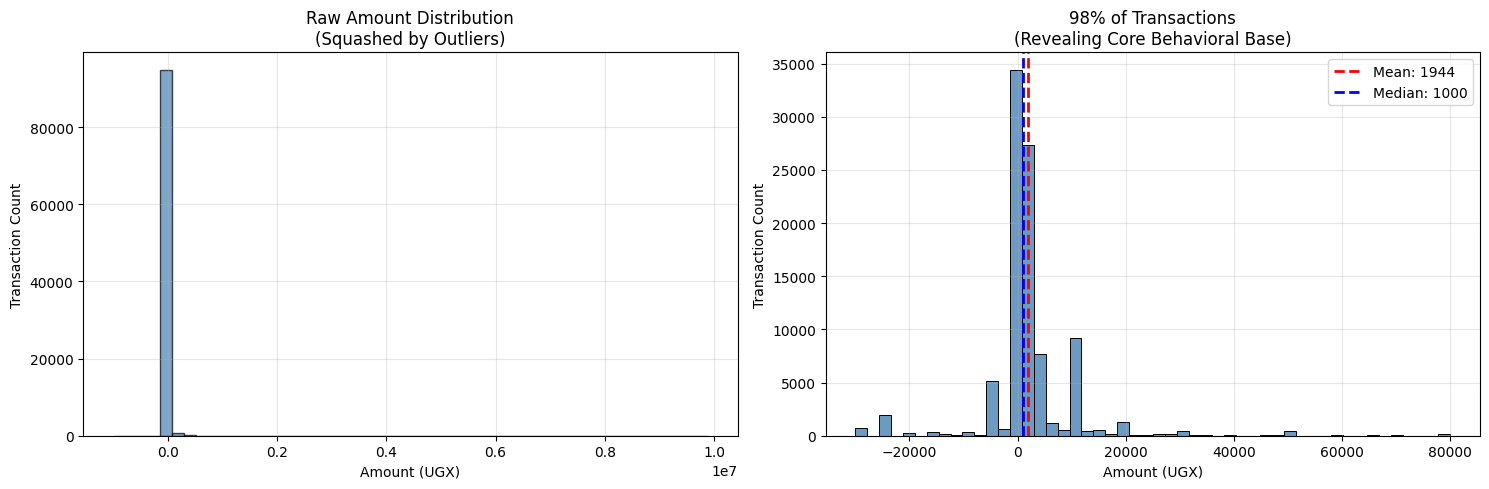

In [11]:
# Calculate percentiles based on your excellent logic
upper_limit = df['Amount'].quantile(0.99)
lower_limit = df['Amount'].quantile(0.01)

# Filter the data
normal_data = df[(df['Amount'] >= lower_limit) & (df['Amount'] <= upper_limit)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Your original view showcasing the extreme scaling issue
axes[0].hist(df['Amount'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Raw Amount Distribution\n(Squashed by Outliers)', fontsize=12)
axes[0].set_xlabel('Amount (UGX)')
axes[0].set_ylabel('Transaction Count')
axes[0].grid(alpha=0.3)

# Plot 2: Your clipped view, but color-coded by Fraud to uncover patterns!
sns.histplot(
    data=normal_data, 
    x='Amount', 
    hue='FraudResult', 
    multiple='stack', 
    bins=50, 
    palette={0: 'steelblue', 1: 'crimson'},
    ax=axes[1],
    edgecolor='black',
    alpha=0.8
)
axes[1].axvline(normal_data['Amount'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {normal_data["Amount"].mean():.0f}')
axes[1].axvline(normal_data['Amount'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {normal_data["Amount"].median():.0f}')
axes[1].set_title('98% of Transactions\n(Revealing Core Behavioral Base)', fontsize=12)
axes[1].set_xlabel('Amount (UGX)')
axes[1].set_ylabel('Transaction Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

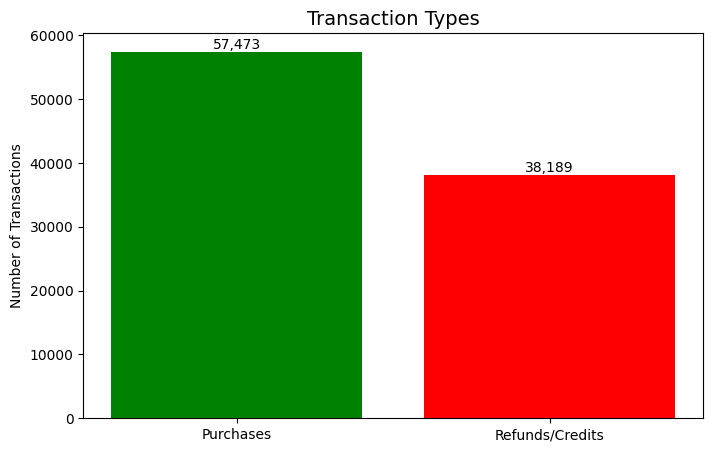


=== SIMPLE SUMMARY ===
Platform GAINS money: 57,473 times (60.1%)
Platform LOSES money: 38,189 times (39.9%)


In [12]:
# Simple bar chart - just count positive vs negative
plt.figure(figsize=(8, 5))

# Count how many positive vs negative
positive_count = (df['Amount'] > 0).sum()
negative_count = (df['Amount'] < 0).sum()

plt.bar(['Purchases', 'Refunds/Credits'], 
        [positive_count, negative_count], 
        color=['green', 'red'])

# Add count labels on bars
plt.text(0, positive_count, f'{positive_count:,}', ha='center', va='bottom')
plt.text(1, negative_count, f'{negative_count:,}', ha='center', va='bottom')

plt.title('Transaction Types', fontsize=14)
plt.ylabel('Number of Transactions')
plt.show()

print("\n=== SIMPLE SUMMARY ===")
print(f"Platform GAINS money: {positive_count:,} times ({positive_count/len(df)*100:.1f}%)")
print(f"Platform LOSES money: {negative_count:,} times ({negative_count/len(df)*100:.1f}%)")

### Outlier Detection

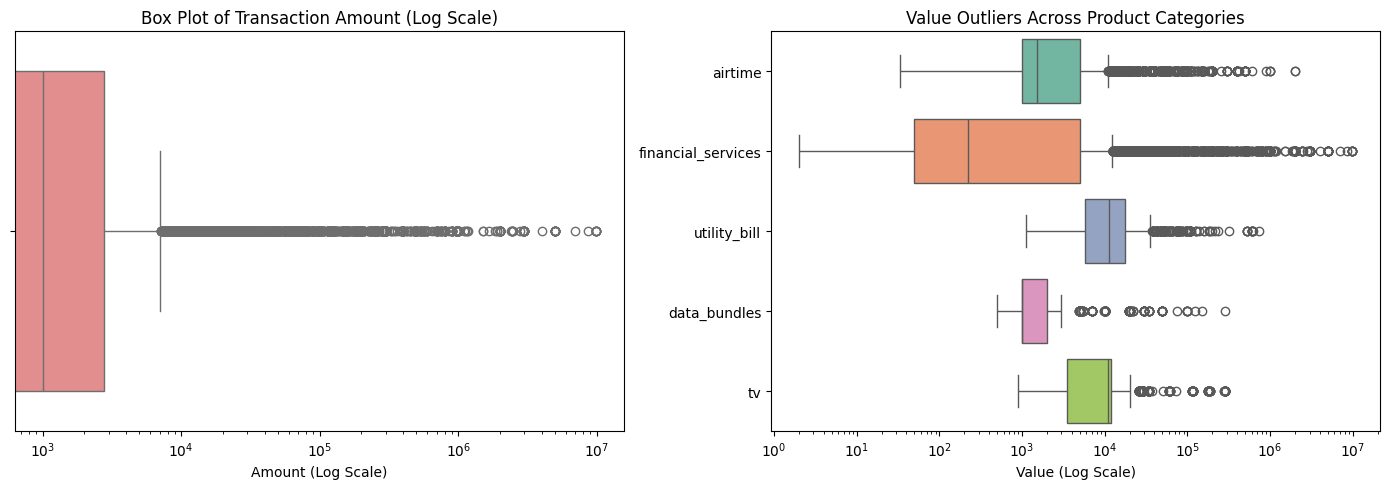

In [13]:
# Create side-by-side box plots for Amount and Value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for Amount (using log scale to handle the huge variance gracefully)
sns.boxplot(data=df, x='Amount', ax=axes[0], color='lightcoral')
axes[0].set_xscale('log')  
axes[0].set_title('Box Plot of Transaction Amount (Log Scale)')
axes[0].set_xlabel('Amount (Log Scale)')

# Boxplot for Value segmented by top Product Categories
top_cats = df['ProductCategory'].value_counts().nlargest(5).index
df_filtered = df[df['ProductCategory'].isin(top_cats)]

# FIXED LINE: Added hue='ProductCategory' and legend=False
sns.boxplot(
    data=df_filtered, 
    y='ProductCategory', 
    x='Value', 
    hue='ProductCategory', 
    legend=False, 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_xscale('log')
axes[1].set_title('Value Outliers Across Product Categories')
axes[1].set_xlabel('Value (Log Scale)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Distribution of Categorical Features Code

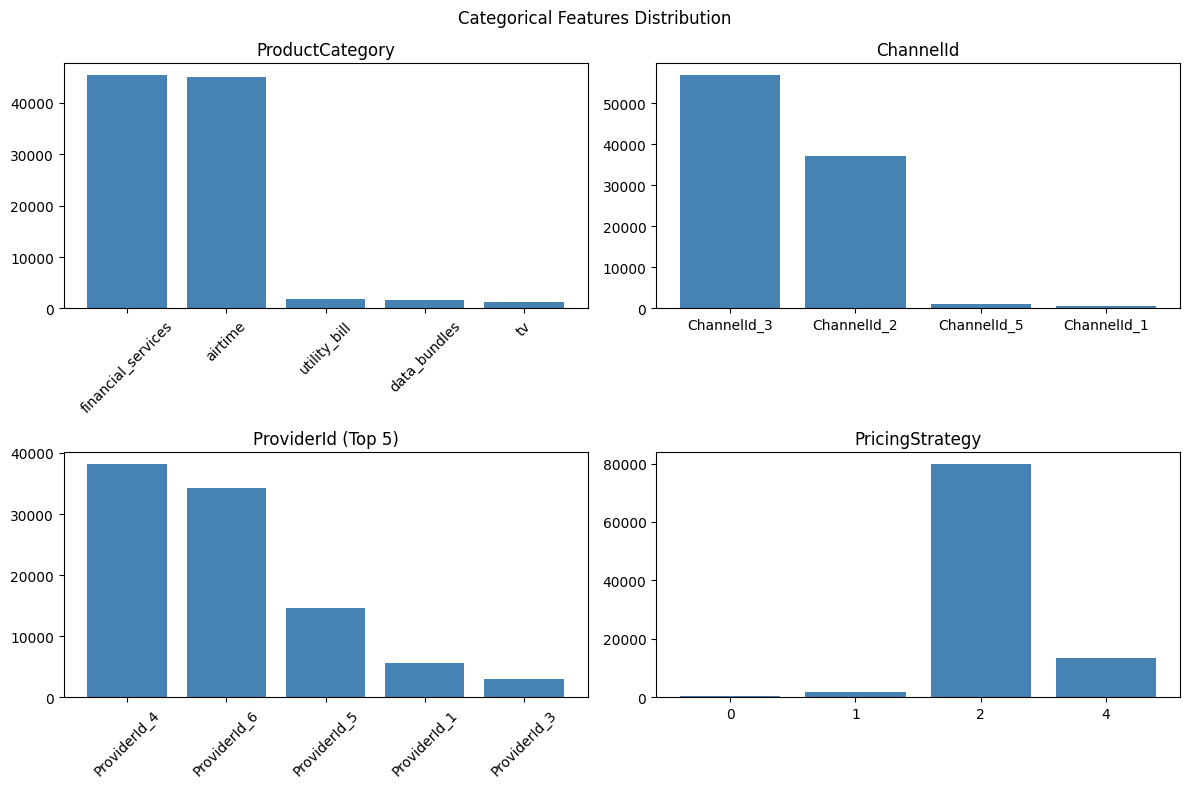

In [14]:
# Alternative: All in one figure with different subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Categorical Features Distribution', fontsize=12)

# Plot 1: ProductCategory (top 5)
ax = axes[0,0]
top_cat = df['ProductCategory'].value_counts().head(5)
ax.bar(top_cat.index, top_cat.values, color='steelblue')
ax.set_title('ProductCategory')
ax.tick_params(axis='x', rotation=45)

# Plot 2: ChannelId
ax = axes[0,1]
top_channel = df['ChannelId'].value_counts()
ax.bar(top_channel.index.astype(str), top_channel.values, color='steelblue')
ax.set_title('ChannelId')

# Plot 3: ProviderId (top 5)
ax = axes[1,0]
top_provider = df['ProviderId'].value_counts().head(5)
ax.bar(top_provider.index, top_provider.values, color='steelblue')
ax.set_title('ProviderId (Top 5)')
ax.tick_params(axis='x', rotation=45)

# Plot 4: PricingStrategy
ax = axes[1,1]
top_price = df['PricingStrategy'].value_counts().sort_index()
ax.bar(top_price.index.astype(str), top_price.values, color='steelblue')
ax.set_title('PricingStrategy')

plt.tight_layout()
plt.show()

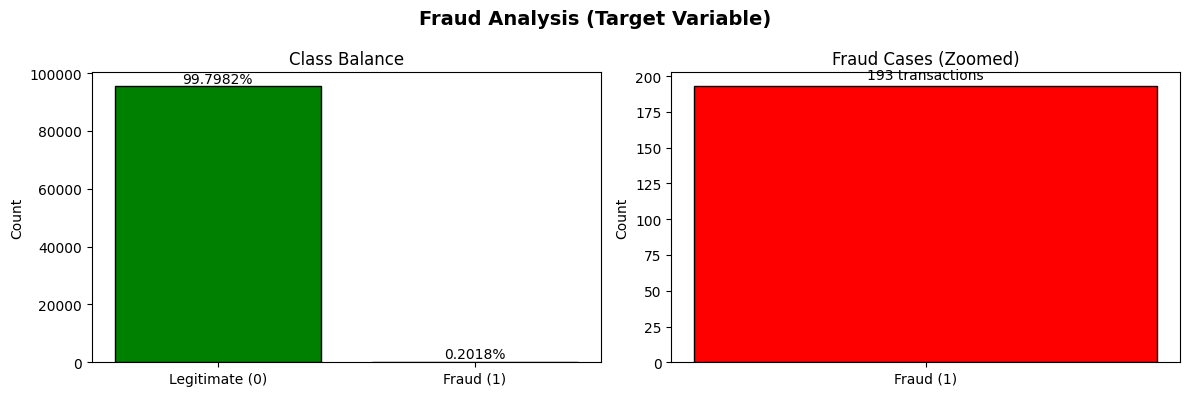


=== FRAUD INSIGHTS ===
Total fraud cases: 193
Fraud rate: 0.201752%


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fraud Analysis (Target Variable)', fontsize=14, fontweight='bold')

# Plot 1: Class balance
fraud_counts = df['FraudResult'].value_counts()
colors = ['green', 'red']
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Balance')
axes[0].set_ylabel('Count')

# Add percentage labels
for i, (label, count) in enumerate(fraud_counts.items()):
    pct = (count / len(df)) * 100
    axes[0].text(i, count + len(df)*0.001, f'{pct:.4f}%', ha='center', va='bottom')

# Plot 2: Zoomed to see fraud (since it's tiny)
axes[1].bar(['Fraud (1)'], [fraud_counts[1]], color='red', edgecolor='black')
axes[1].set_title('Fraud Cases (Zoomed)')
axes[1].set_ylabel('Count')
# Add exact number
axes[1].text(0, fraud_counts[1] + 5, f'{fraud_counts[1]:,} transactions', ha='center')

plt.tight_layout()
plt.show()

print("\n=== FRAUD INSIGHTS ===")
print(f"Total fraud cases: {fraud_counts[1]:,}")
print(f"Fraud rate: {fraud_counts[1]/len(df)*100:.6f}%")


### Correlation Analysis

=== PRICINGSTRATEGY vs FRAUD ===
FraudResult          0     1
PricingStrategy             
0                90.65  9.35
1                99.63  0.37
2                99.83  0.17
4                99.92  0.08


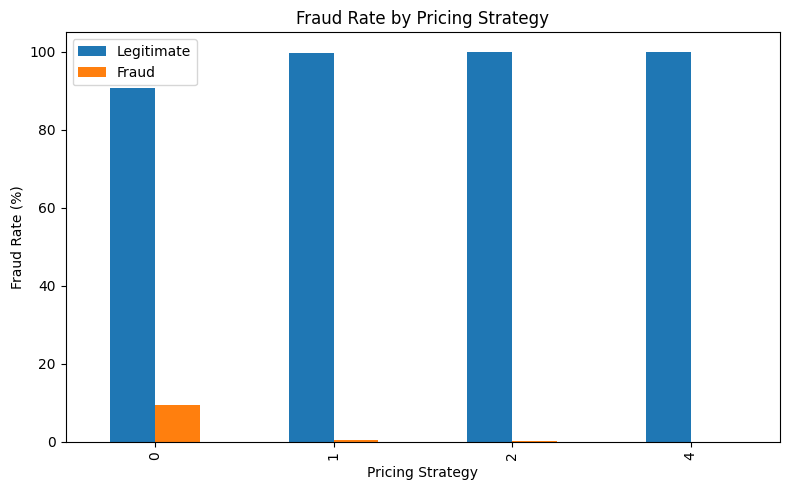

In [16]:
# Example: PricingStrategy vs FraudResult
print("=== PRICINGSTRATEGY vs FRAUD ===")
cross_tab = pd.crosstab(df['PricingStrategy'], df['FraudResult'], normalize='index') * 100
print(cross_tab.round(2))

# Visualize
cross_tab.plot(kind='bar', figsize=(8, 5))
plt.title('Fraud Rate by Pricing Strategy')
plt.xlabel('Pricing Strategy')
plt.ylabel('Fraud Rate (%)')
plt.legend(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

=== AVERAGE AMOUNT BY PRODUCT CATEGORY ===
                         mean   median  count
ProductCategory                              
transport           170240.00  75000.0     25
ticket               96696.76  80000.0    216
utility_bill         17232.86  10000.0   1920
tv                   16641.13  11000.0   1279
financial_services   11435.56    -50.0  45405
movies                7734.29   5000.0    175
data_bundles          3402.17   1000.0   1613
airtime                822.96   1000.0  45027
other                  500.00    500.0      2


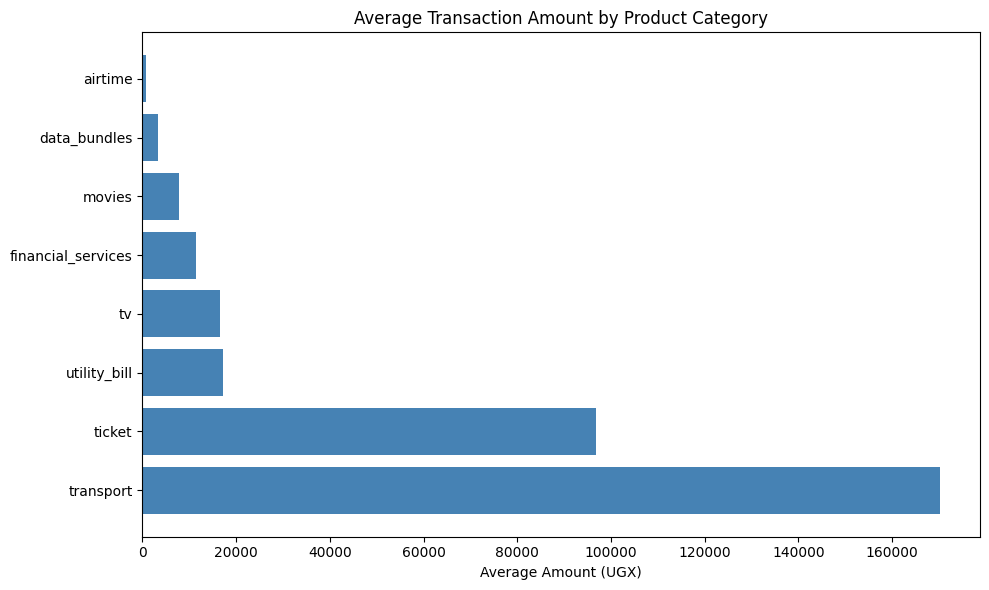

In [17]:
# Compare Amount across ProductCategory
print("=== AVERAGE AMOUNT BY PRODUCT CATEGORY ===")
category_avg = df.groupby('ProductCategory')['Amount'].agg(['mean', 'median', 'count'])
category_avg = category_avg.sort_values('mean', ascending=False)
print(category_avg.round(2).head(10))

# Visualize
plt.figure(figsize=(10, 6))
top_categories = df.groupby('ProductCategory')['Amount'].mean().sort_values(ascending=False).head(8)
plt.barh(range(len(top_categories)), top_categories.values, color='steelblue')
plt.yticks(range(len(top_categories)), top_categories.index)
plt.title('Average Transaction Amount by Product Category')
plt.xlabel('Average Amount (UGX)')
plt.tight_layout()
plt.show()


----------------------------------------
1. Amount vs Value Correlation
----------------------------------------
Correlation coefficient: 0.9897


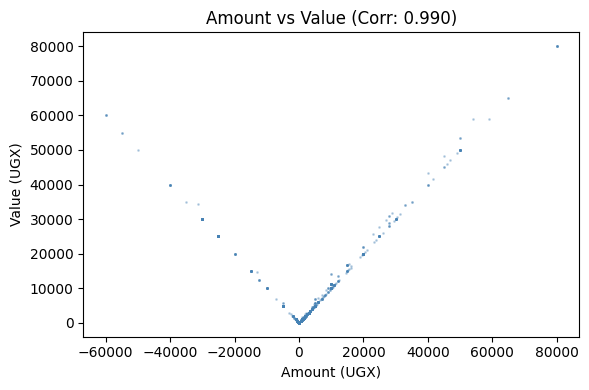

In [18]:
if 'Value' in df.columns:
    print("\n" + "-"*40)
    print("1. Amount vs Value Correlation")
    print("-"*40)
    
    corr_amount_value = df['Amount'].corr(df['Value'])
    print(f"Correlation coefficient: {corr_amount_value:.4f}")
    
    if abs(corr_amount_value) > 0.99:
        print("Interpretation: Nearly perfect correlation (0.999+)")
        print("Conclusion: Value = |Amount| - this column is redundant")
        print("Recommendation: Drop 'Value' column in feature engineering")
    
    # Simple visualization
    plt.figure(figsize=(6, 4))
    # Sample and cap outliers for better view
    limit = df['Amount'].quantile(0.99)
    sample_df = df[df['Amount'].abs() <= limit].sample(n=3000, random_state=42)
    plt.scatter(sample_df['Amount'], sample_df['Value'], alpha=0.3, s=1, color='steelblue')
    plt.xlabel('Amount (UGX)')
    plt.ylabel('Value (UGX)')
    plt.title(f'Amount vs Value (Corr: {corr_amount_value:.3f})')
    plt.tight_layout()
    plt.show()

#### Customer-Level Analysis

In [20]:
# Customer transaction summary
customer_summary = df.groupby('CustomerId').agg(
    total_transactions=('TransactionId', 'count'),
    total_spent=('Amount', lambda x: x[x > 0].sum()),
    total_refunds=('Amount', lambda x: x[x < 0].abs().sum()),
    avg_transaction=('Amount', 'mean'),
    unique_products=('ProductId', 'nunique'),
    unique_categories=('ProductCategory', 'nunique'),
    refund_rate=('Amount', lambda x: (x < 0).sum() / len(x))
).reset_index()

print("=== CUSTOMER-LEVEL INSIGHTS ===")
print(f"Total customers: {len(customer_summary):,}")
print(f"Avg transactions per customer: {customer_summary['total_transactions'].mean():.1f}")
print(f"Customer with most transactions: {customer_summary['total_transactions'].max()}")
print(f"Customers with >100 transactions: {(customer_summary['total_transactions'] > 100).sum()}")
print(f"Customers with refund rate >50%: {(customer_summary['refund_rate'] > 0.5).sum()}")

=== CUSTOMER-LEVEL INSIGHTS ===
Total customers: 3,742
Avg transactions per customer: 25.6
Customer with most transactions: 4091
Customers with >100 transactions: 182
Customers with refund rate >50%: 286


#### Time-Based Patterns

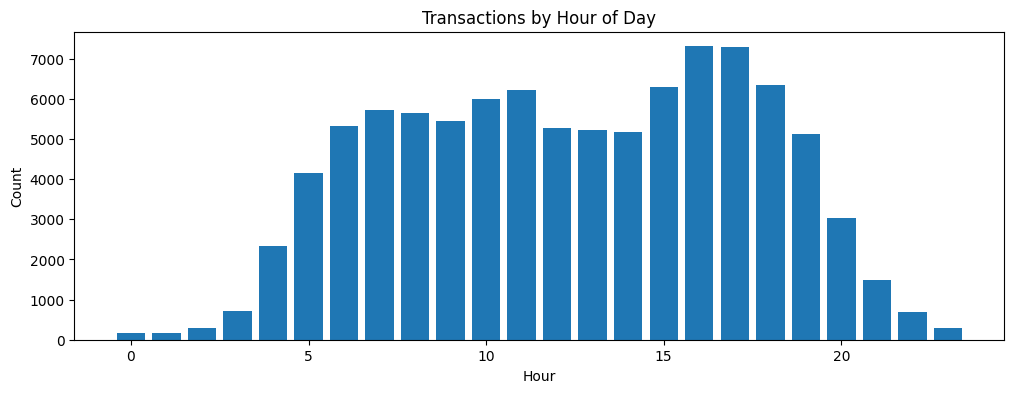

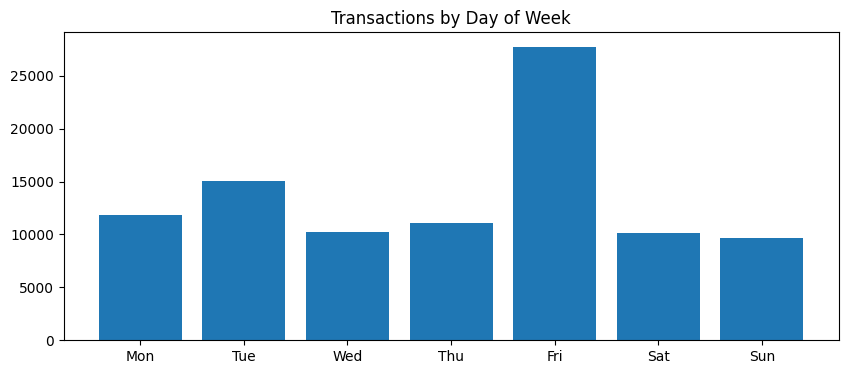

Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00
Total days: 90


In [21]:
# Convert to datetime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Extract time features
df['Hour'] = df['TransactionStartTime'].dt.hour
df['DayOfWeek'] = df['TransactionStartTime'].dt.dayofweek
df['Month'] = df['TransactionStartTime'].dt.month

# Plot transaction volume by hour
plt.figure(figsize=(12, 4))
hourly = df.groupby('Hour').size()
plt.bar(hourly.index, hourly.values)
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

# Plot by day of week
plt.figure(figsize=(10, 4))
daily = df.groupby('DayOfWeek').size()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(days, daily.values)
plt.title('Transactions by Day of Week')
plt.show()

print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")
print(f"Total days: {(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days}")

####  Customer Segmentation Preview 

=== RFM DISTRIBUTIONS (Before Clustering) ===
Recency - Min: 0, Max: 90, Mean: 30.5
Frequency - Min: 1, Max: 4091, Mean: 25.6
Monetary - Min: 0, Max: 83466000, Mean: 211864


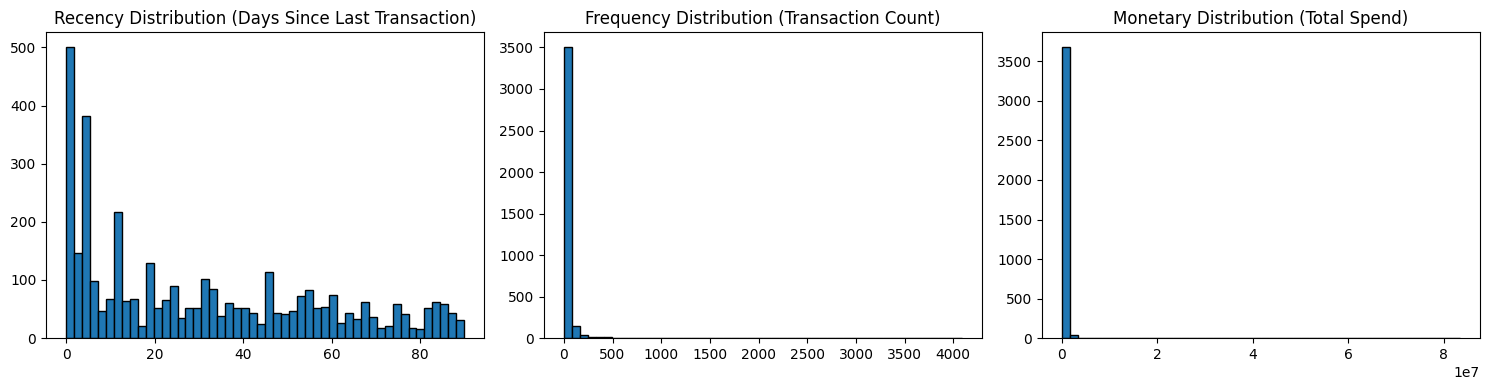

In [22]:
# ADD THIS - Calculate RFM metrics for EDA
snapshot_date = df['TransactionStartTime'].max()

rfm = df.groupby('CustomerId').agg(
    recency=('TransactionStartTime', lambda x: (snapshot_date - x.max()).days),
    frequency=('TransactionId', 'count'),
    monetary=('Amount', lambda x: x[x > 0].sum())
).reset_index()

print("=== RFM DISTRIBUTIONS (Before Clustering) ===")
print(f"Recency - Min: {rfm['recency'].min()}, Max: {rfm['recency'].max()}, Mean: {rfm['recency'].mean():.1f}")
print(f"Frequency - Min: {rfm['frequency'].min()}, Max: {rfm['frequency'].max()}, Mean: {rfm['frequency'].mean():.1f}")
print(f"Monetary - Min: {rfm['monetary'].min():.0f}, Max: {rfm['monetary'].max():.0f}, Mean: {rfm['monetary'].mean():.0f}")

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm['recency'], bins=50, edgecolor='black')
axes[0].set_title('Recency Distribution (Days Since Last Transaction)')
axes[1].hist(rfm['frequency'], bins=50, edgecolor='black')
axes[1].set_title('Frequency Distribution (Transaction Count)')
axes[2].hist(rfm['monetary'], bins=50, edgecolor='black')
axes[2].set_title('Monetary Distribution (Total Spend)')
plt.tight_layout()
plt.show()

In [23]:
# ProviderId vs Fraud
provider_fraud = df.groupby('ProviderId')['FraudResult'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("=== FRAUD RATE BY PROVIDER ===")
print(provider_fraud.head(10))

# ChannelId vs Fraud
channel_fraud = df.groupby('ChannelId')['FraudResult'].mean().sort_values(ascending=False)
print("\n=== FRAUD RATE BY CHANNEL ===")
print(channel_fraud)

=== FRAUD RATE BY PROVIDER ===
                  mean  count
ProviderId                   
ProviderId_3  0.020752   3084
ProviderId_1  0.010101   5643
ProviderId_5  0.004401  14542
ProviderId_4  0.000131  38189
ProviderId_6  0.000088  34186
ProviderId_2  0.000000     18

=== FRAUD RATE BY CHANNEL ===
ChannelId
ChannelId_1    0.007435
ChannelId_3    0.003232
ChannelId_2    0.000135
ChannelId_5    0.000000
Name: FraudResult, dtype: float64


=== CUSTOMER CONCENTRATION ===
Top 1% of customers account for 24.4% of transactions
Top 10% of customers account for 62.9% of transactions


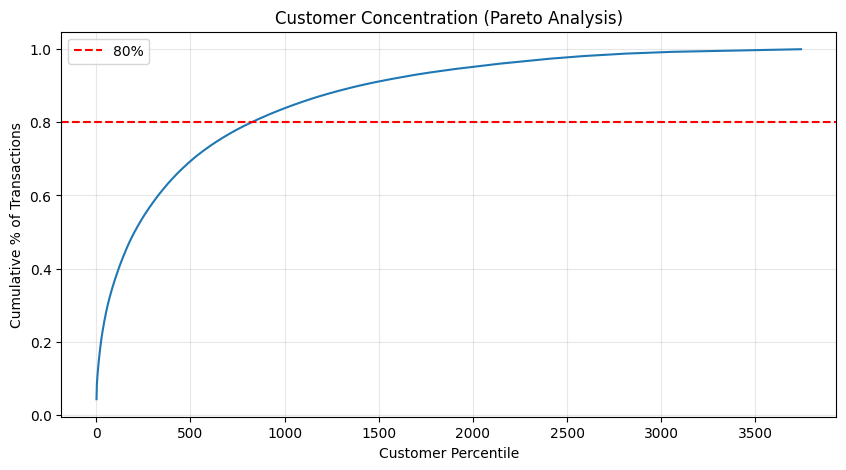

In [24]:

# Check if few customers drive most transactions
customer_tx = df.groupby('CustomerId').size().sort_values(ascending=False)
cumulative = customer_tx.cumsum() / customer_tx.sum()

print("=== CUSTOMER CONCENTRATION ===")
print(f"Top 1% of customers account for {cumulative.iloc[int(len(cumulative)*0.01)]*100:.1f}% of transactions")
print(f"Top 10% of customers account for {cumulative.iloc[int(len(cumulative)*0.1)]*100:.1f}% of transactions")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative)+1), cumulative.values)
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.xlabel('Customer Percentile')
plt.ylabel('Cumulative % of Transactions')
plt.title('Customer Concentration (Pareto Analysis)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## EDA Insights

### 1. Data Quality
- **No missing values** across all 16 columns (95,662 complete transactions)
- Data is clean and ready for feature engineering

### 2. Class Imbalance
- **Fraud rate: 0.2%** (193 out of 95,662 transactions)
- Imbalance ratio: 495 legitimate : 1 fraud
- **Action**: Will need SMOTE, class weights, or undersampling for modeling

### 3. Transaction Amount Distribution
- **Highly skewed right** (mean 6,718 UGX, median 1,000 UGX)
- **40% of transactions are negative** (refunds/credits), concentrated in financial_services
- Outliers range up to 9.88M UGX
- **Action**: Apply log transform or capping for modeling

### 4. Categorical Feature Concentration
| Feature | Dominant Value | % |
|---------|---------------|-----|
| ProductCategory | financial_services | 47% |
| ChannelId | Channel 3 | 60% |
| ProviderId | Provider 4 | 40% |
| PricingStrategy | Strategy 1 | 78% |

- **Action**: Group rare categories into "Other"; consider dropping low-variance features

### 5. Correlation Findings
- **Amount vs Value**: 0.99 correlation → Value is redundant (Value = |Amount|)
- **Amount vs FraudResult**: 0.56 correlation (fraud tends to have larger amounts)
- **Action**: Drop 'Value' column in feature engineering

### 6. Customer Concentration
- **3,742 unique customers**; avg 25.6 transactions per customer
- One customer (CustomerId_7343) has 4,091 transactions (43x average)
- **Top 10% of customers drive 63% of transaction volume** (Pareto distribution)
- **286 customers (7.6%) have refund rates >50%** → potential high-risk segment
- **Action**: Cap or log-transform customer-level aggregates; consider outlier handling

### 7. Temporal Patterns
- **Friday volume doubles other weekdays** (~28,000 vs ~14,000 transactions)
- **Peak hours**: 8-10 AM and 2-4 PM (business hours)
- Date range: 90 days (Nov 15, 2018 - Feb 13, 2019)
- **Action**: Extract hour, day_of_week, month; create `is_friday` flag

### 8. RFM Analysis (for Proxy Target)
| Metric | Min | Max | Mean |
|--------|-----|-----|------|
| Recency | 0 days | 90 days | 30.5 days |
| Frequency | 1 tx | 4,091 tx | 25.6 tx |
| Monetary | 0 UGX | 83.5M UGX | 212K UGX |

- **Action for Task 4**: Use K-Means clustering on scaled RFM features; label disengaged cluster (high recency, low frequency, low monetary) as high-risk (1)

### 9. Fraud Patterns by Provider & Channel
- **ProviderId 3**: 2.08% fraud rate (highest)
- **ProviderId 6**: 0.009% fraud rate (lowest)
- **ChannelId 1**: 0.74% fraud rate (highest)
- **ChannelId 2**: 0.014% fraud rate (lowest)
- **Action**: Keep ProviderId and ChannelId as categorical features (one-hot encode)
